In [1]:
import feather
import pandas as pd
import talib
import numpy as np

# Read DataFrame from feather file
df_path = '/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-1m-futures.feather'
df = feather.read_dataframe(df_path)

# Apply TEMA (Triple Exponential Moving Average) with a period of 50 to 'close' column
df['TEMA'] = talib.TEMA(df['close'], timeperiod=50)

# Determine the trend direction based on TEMA
df['trend_direction'] = np.select([df['TEMA'] > df['TEMA'].shift(1), df['TEMA'] < df['TEMA'].shift(1)],
                                  ['UP', 'DOWN'], default='UNCHANGED')

# Identify rows where the trend direction changes and is not 'UNCHANGED'
df['trend_change_point'] = (df['trend_direction'] != df['trend_direction'].shift(1)).astype(int)
trend_change_points = df[df['trend_change_point'].eq(1) & df['trend_direction'].ne('UNCHANGED')].copy()

# Calculate the duration of each trend
trend_change_points.loc[:, 'trend_duration'] = trend_change_points.index.to_series().diff().fillna(0)

# Round 'TEMA' and 'volume' columns to 2 decimal places
trend_change_points.loc[:, ['TEMA', 'volume']] = trend_change_points[['TEMA', 'volume']].round(2)

# Convert 'date' column to a formatted string
if 'date' in trend_change_points.columns:
    trend_change_points.loc[:, 'date'] = trend_change_points['date'].dt.strftime('%Y-%m-%d %H:%M')




In [3]:
trend_change_points

,date,open,high,low,close,volume,TEMA,trend_direction,trend_change_point,trend_duration
148,2019-11-27 10:13:00+00:00,133.00,133.00,133.00,133.00,0.00,132.91,UP,1,0.0
209,2019-11-27 11:14:00+00:00,143.58,143.62,143.27,143.27,123.35,145.19,DOWN,1,61.0
210,2019-11-27 11:15:00+00:00,143.27,143.53,143.27,143.46,193.59,145.19,UP,1,1.0
212,2019-11-27 11:17:00+00:00,143.59,143.59,143.34,143.46,109.31,145.19,DOWN,1,2.0
214,2019-11-27 11:19:00+00:00,143.34,143.88,143.13,143.88,79.46,145.19,UP,1,2.0
...,...,...,...,...,...,...,...,...,...,...
2127178,2023-12-13 12:43:00+00:00,2180.59,2182.50,2180.59,2182.36,937.93,2182.15,UP,1,6.0
2127180,2023-12-13 12:45:00+00:00,2181.18,2181.60,2180.74,2180.75,565.91,2182.14,DOWN,1,2.0
2127185,2023-12-13 12:50:00+00:00,2179.24,2180.90,2179.22,2180.90,604.86,2181.69,UP,1,5.0
2127198,2023-12-13 13:03:00+00:00,2183.46,2183.47,2182.62,2182.63,583.73,2183.99,DOWN,1,13.0


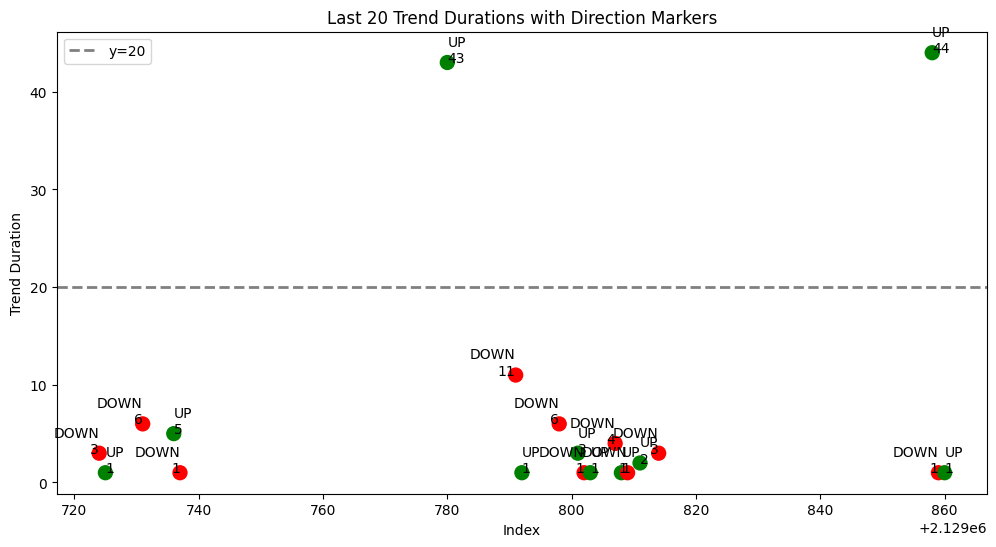

In [4]:
import matplotlib.pyplot as plt

# Assuming trend_change_points is already defined
trend_duration_plot = trend_change_points.copy()

# Shifting 'trend_direction' column by one place
trend_duration_plot['trend_direction'] = trend_duration_plot['trend_direction'].shift(1)

# Removing rows with NaN values in 'trend_duration' column
trend_duration_plot.dropna(subset=['trend_duration'], inplace=True)

# Define window size for plotting
window_size = 20

# Selecting the last 'window_size' rows for plotting
trend_duration_plot = trend_duration_plot.tail(window_size)

# Plot setup
plt.figure(figsize=(12, 6))
color_map = {'UP': 'green', 'DOWN': 'red', 'UNCHANGED': 'blue'}
plt.scatter(trend_duration_plot.index, trend_duration_plot['trend_duration'], 
            c=trend_duration_plot['trend_direction'].map(color_map), 
            marker='o', s=100)

# Draw a horizontal line at y=20
plt.axhline(y=20, color='gray', linestyle='--', linewidth=2, label='y=20')

# Axis labels and title
plt.xlabel('Index')
plt.ylabel('Trend Duration')
plt.title(f'Last {window_size} Trend Durations with Direction Markers')

# Adding labels for each point
for index, row in trend_duration_plot.iterrows():
    text_align = 'right' if row['trend_direction'] == 'DOWN' else 'left'
    plt.text(index, row['trend_duration'], f"{row['trend_direction']}\n{int(row['trend_duration'])}", ha=text_align)

# Display plot
plt.legend()  # Add legend for the horizontal line
plt.show()
